# 🎯 Detecção de Anomalias com Autoencoders: AE vs. VAE

**Disciplina:** GENERATIVE AI & ADAVANCED NETS

**Curso:** Tecnólogo em Inteligência Artificial

---

## 🎯 Objetivos de Aprendizagem

Ao final desta aula prática, você será capaz de:

1. **Construir** um sistema de detecção de anomalias baseado em **Autoencoders**.
2. **Compreender** as diferenças entre um **Autoencoder tradicional (AE)** e um **Variational Autoencoder (VAE)**.
3. **Analisar** como a organização do **espaço latente** influencia a reconstrução dos dados.
4. **Avaliar** o comportamento dos modelos diante de diferentes tipos de falhas em equipamentos.
5. **Utilizar** o erro de reconstrução como **Score de Anomalia** para apoiar o monitoramento preditivo.

---

## 🏭 Contexto do Problema

Em ambientes industriais, sensores monitoram continuamente o comportamento de máquinas e equipamentos.

O desafio é identificar **desvios em relação ao comportamento normal** antes que uma falha cause impacto operacional.

Nesta aula, vamos utilizar um conjunto de dados **adaptado a partir do dataset KAIST (Mendeley)** (https://data.mendeley.com/datasets/ztmf3m7h5x/), estruturado para representar, de forma didática, diferentes condições de operação de uma máquina rotativa.

Os dados consideram três variáveis de monitoramento:

- **Vibração - mm/s / g**: Dados sísmicos extraídos dos acelerômetros.
- **Temperatura - °C**: Termopares do equipamento. Falhas geram atrito e picos de calor.
- **Corrente elétrica - Amperes**: Transformadores de corrente demonstrando o esforço do motor.

Nosso objetivo será utilizar os exemplos de **operação normal** para que os modelos aprendam o padrão esperado de funcionamento e, posteriormente, identificar comportamentos anômalos a partir do **erro de reconstrução**.

## 🛠️ Etapa 1: Coleta e Preparação dos Dados

Nesta etapa, vamos carregar e preparar os dados que serão utilizados no treinamento dos modelos.

O conjunto de dados representa o comportamento de uma máquina rotativa monitorada por sensores de:

- **Vibração**
- **Temperatura**
- **Corrente elétrica**

Nosso objetivo será utilizar os exemplos de **operação normal** para que os modelos aprendam o padrão esperado de funcionamento.

> **Estratégia da aula:** os modelos serão treinados principalmente com dados normais e, posteriormente, avaliados utilizando também dados contendo diferentes tipos de falha.

In [ ]:
#!pip install plotly -q
!pip install nptdms -q

In [ ]:
import os
import random
import requests
import numpy as np
import tensorflow as tf
import scipy.io
from nptdms import TdmsFile
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, clear_output
import time

print("Bibliotecas carregadas com sucesso!")

In [ ]:
def set_seeds(seed=42):
    # 1. Seed do ambiente do Python e biblioteca nativa random
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)

    # 2. Seed do NumPy (usado na geração dos dados sintéticos)
    np.random.seed(seed)

    # 3. Seed do TensorFlow/Keras (usado na inicialização dos pesos e no VAE)
    tf.random.set_seed(seed)

    # 4. Força determinismo em operações na GPU/CPU (TensorFlow 2.9+)
    tf.config.experimental.enable_op_determinism()

    print(f"🌱 Sementes de aleatoriedade fixadas em: {seed}")

# Chama a função no topo do seu código
set_seeds(42)

In [ ]:
# URL RAW do arquivo JSON no seu GitHub
RAW_URL = "https://raw.githubusercontent.com/mateusdalbone-fiap/fiap-genai-advnets/main/datasets/aula_vae/kaist_dataset.json"

# 1. Lê o JSON direto da Web em 1 linha
data = requests.get(RAW_URL).json()

# 2. Converte de volta para NumPy arrays
X_train_normal = np.array(data['X_train_normal'])
X_test_normal = np.array(data['X_test_normal'])
X_test_failures = {k: np.array(v) for k, v in data['X_test_failures'].items()}

print("✅ Dataset carregado com sucesso!")

In [ ]:
# Seleciona uma amostra normal e uma de falha
normal = X_test_normal[0]
failure = X_test_failures[list(X_test_failures.keys())[0]][0]

time = np.arange(normal.shape[0])

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

names = ["Vibração", "Temperatura", "Corrente"]

for i in range(3):
    axs[i].plot(time, normal[:, i], label="Operação Normal")
    axs[i].plot(time, failure[:, i], label="Falha", alpha=0.8)
    axs[i].set_ylabel(names[i])
    axs[i].grid(alpha=0.3)

axs[0].legend()
axs[-1].set_xlabel("Tempo")

plt.suptitle("Sinais dos Sensores de uma Máquina Rotativa")
plt.tight_layout()
plt.show()

### 🧠 Fundamentos Teóricos: Modelos Generativos Baseados em Espaço Latente

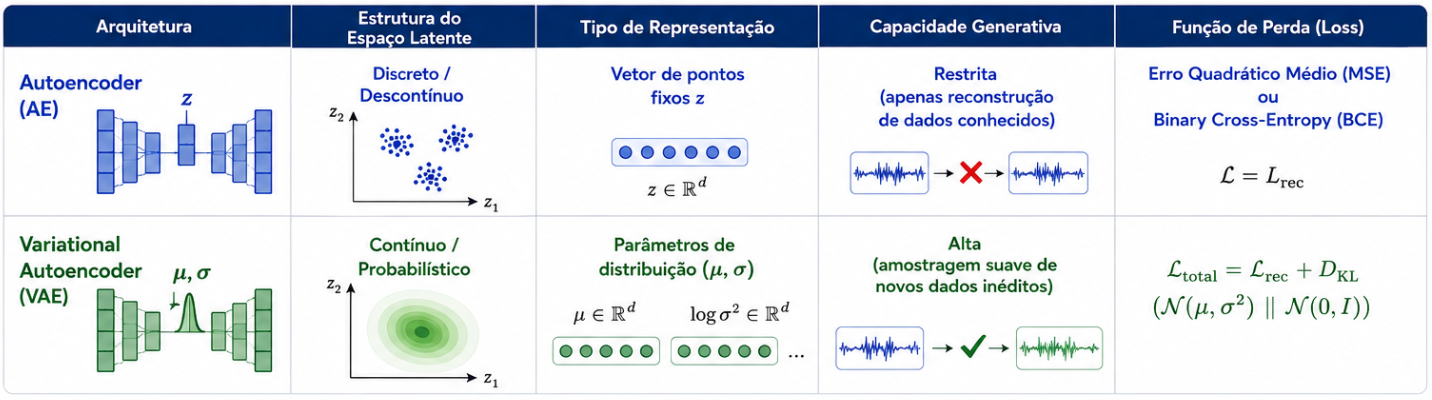

## 🛠️ Etapa 2: Autoencoder Tradicional (AE)

### Como o Autoencoder aprende o comportamento normal?

O **Autoencoder (AE)** é uma arquitetura formada por duas partes principais:

- **Encoder:** transforma a entrada em uma representação compacta no **espaço latente**.
- **Decoder:** utiliza essa representação para reconstruir a entrada original.

Neste exemplo, vamos comprimir os sinais dos três sensores em um **espaço latente de apenas duas dimensões**.

A ideia é que o modelo aprenda uma representação compacta dos padrões presentes nos dados normais.

### ⚠️ Uma limitação importante

O Autoencoder tradicional é **determinístico**: cada entrada é mapeada para um ponto específico do espaço latente.

Isso significa que o modelo não impõe uma estrutura explícita sobre esse espaço.

Como consequência, podem surgir regiões pouco representadas ou até mesmo regiões vazias entre os padrões aprendidos.

Esse comportamento será importante para entendermos, na sequência, a motivação para utilizar um **Variational Autoencoder (VAE)**.

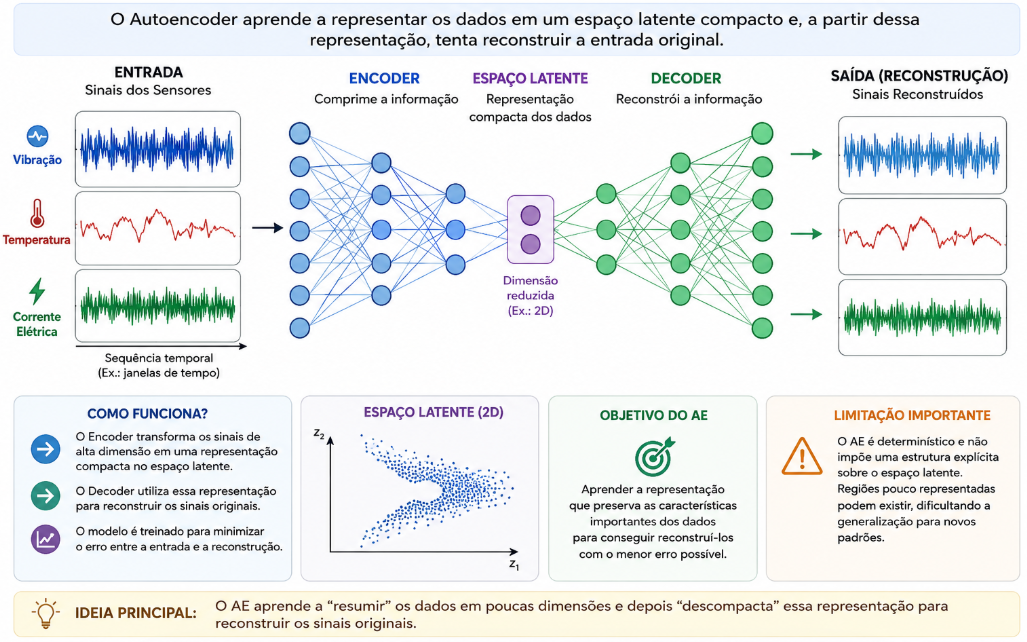

In [ ]:
# Dimensão do espaço latente (embedding comprimido)
# Como está igual a 2, poderemos visualizar os dados em um gráfico 2D.
LATENT_DIM = 2

# Comprimento da sequência temporal de entrada.
# Cada amostra possui 100 instantes de tempo.
SEQ_LEN = 100

# Define sementes aleatórias para garantir reprodutibilidade.
# Assim, os pesos iniciais e resultados tendem a ser os mesmos
# em diferentes execuções.
set_seeds(42)

In [ ]:
# ============================================================
# Construir o Encoder do Autoencoder com keras
#
# O Encoder é responsável por comprimir a sequência original
# em uma representação latente de baixa dimensão.
# ============================================================

# TODO Crie o Encoder usando keras.models.Sequential
ae_encoder = keras.models.Sequential([

    # TODO Como cada amostra possui SEQ_LEN instantes de tempo
    # e 3 variáveis por instante, defina uma camada de entrada
    # usando Input(shape=(SEQ_LEN, 3))
    ...,

    # TODO Converta a matriz (SEQ_LEN, 3) em um vetor 1D
    # para permitir o uso de camadas Dense
    ...,

    # TODO Crie uma camada oculta usando Dense com
    # 64 neurônios e activation="relu"
    # para aprender relações não lineares
    ...,

    # TODO Crie a camada latente usando Dense.
    # Utilize LATENT_DIM neurônios para representar
    # o espaço latente desejado.
    #
    # Utilize activation="linear" para permitir
    # valores positivos e negativos no espaço latente.
    ...
], name="ae_encoder")

In [ ]:
# ============================================================
# Construir o Decoder do Autoencoder com keras
#
# O Decoder recebe o vetor latente e tenta reconstruir
# a sequência original.
# ============================================================

# TODO Crie o Decoder usando keras.models.Sequential
ae_decoder = keras.models.Sequential([

    # TODO Como a entrada do Decoder é o vetor latente,
    # defina uma camada de entrada com shape=(LATENT_DIM,)
    ...,

    # TODO Crie uma camada oculta usando Dense com
    # 64 neurônios e activation="relu"
    # para expandir a representação comprimida
    ...,

    # TODO Reconstrua todos os valores da sequência.
    #
    # Como cada amostra possui SEQ_LEN timesteps
    # e 3 variáveis por timestep, utilize
    # SEQ_LEN * 3 neurônios.
    #
    # Utilize activation="linear" pois queremos
    # reconstruir valores contínuos.
    ...,

    # TODO Reorganize o vetor reconstruído para o
    # formato original da série temporal:
    # (SEQ_LEN, 3)
    ...
], name="ae_decoder")

In [ ]:
# TODO Crie o Autoencoder completo empilhando
# o ae_encoder e ae_decoder em um modelo Sequential
autoencoder = keras.models.Sequential([
    ...,
    ...
], name="autoencoder")

In [ ]:
# TODO Compile o modelo utilizando:
#
# optimizer='adam'
# - Algoritmo de otimização responsável por atualizar os pesos.
#
# loss='mse'
# - Mean Squared Error.
# - Mede a diferença entre o sinal original e o reconstruído.
autoencoder.compile(...)

# TODO Treine o Autoencoder utilizando:
# X_train_normal como entrada
# - Contém apenas exemplos considerados normais.
# X_train_normal como saída desejada
# - Em Autoencoders o objetivo é reconstruir a própria entrada.
# epochs=30
# - Número de vezes que o modelo percorrerá todo o conjunto
#   de treinamento.
# batch_size=32
# - Quantidade de amostras utilizadas a cada atualização
#   dos pesos.

autoencoder.fit(...)

In [ ]:
sample = X_train_normal[:1]

# Gera representação latente
latent_vector = ae_encoder.predict(sample)
latent_vector

In [ ]:
decoded_signal = ae_decoder.predict(latent_vector)

for t in range(3):
    print(f"\nTimestep {t}")

    print(
        f"Original     : "
        f"[{sample[0,t,0]:7.3f}, {sample[0,t,1]:7.3f}, {sample[0,t,2]:7.3f}]"
    )

    print(
        f"Reconstruído : "
        f"[{decoded_signal[0,t,0]:7.3f}, {decoded_signal[0,t,1]:7.3f}, {decoded_signal[0,t,2]:7.3f}]"
    )

In [ ]:
sensor_names = ["Vibração", "Temperatura", "Corrente"]
timesteps = np.arange(3)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for sensor in range(3):
    axs[sensor].plot(
        timesteps,
        sample[0, :3, sensor],
        'o-',
        label='Original'
    )

    axs[sensor].plot(
        timesteps,
        decoded_signal[0, :3, sensor],
        's--',
        label='Reconstruído'
    )

    axs[sensor].set_title(sensor_names[sensor])
    axs[sensor].set_xticks(timesteps)
    axs[sensor].set_xlabel("Timestep")
    axs[sensor].grid(True, alpha=0.3)

axs[0].legend()

plt.tight_layout()
plt.show()

## 🛠️ Etapa 3: Variational Autoencoder (VAE)

### Do ponto para uma distribuição

O **Variational Autoencoder (VAE)** modifica a forma como o Encoder representa os dados.

Em vez de produzir diretamente um único ponto no espaço latente, o Encoder estima os parâmetros de uma **distribuição de probabilidade**:

- **Média (`μ`)**
- **Variância (`σ²`)**

A partir dessa distribuição, o modelo realiza uma amostragem para obter a representação latente utilizada pelo Decoder.

### 💡 Por que isso é importante?

Além do erro de reconstrução, o VAE possui uma **regularização probabilística** que incentiva o espaço latente a assumir uma estrutura contínua e organizada.

Com isso, regiões próximas no espaço latente tendem a representar comportamentos também próximos.

Essa característica torna o VAE especialmente interessante quando queremos:

- representar variações do comportamento normal;
- explorar o espaço latente;
- gerar novas amostras;
- identificar comportamentos que se afastam do padrão aprendido.

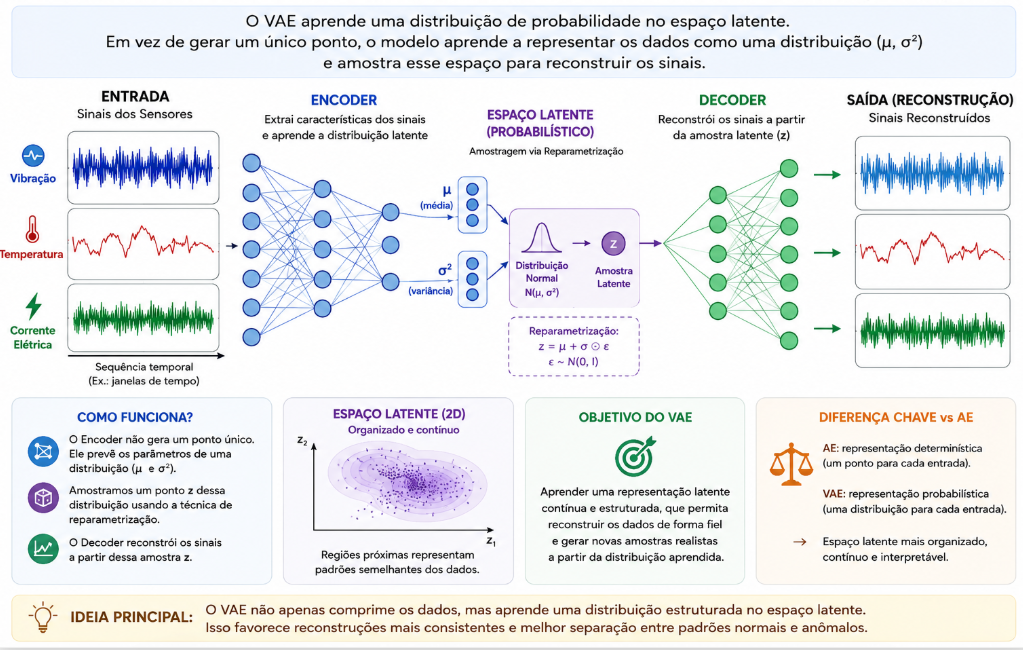

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:
# --- VAE (MSE + KL Divergence) ---
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            # Erro de Reconstrução
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(keras.losses.mse(data, reconstruction), axis=(1,)))
            # Regularização do Espaço Latente (A mágica do VAE)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        return {"loss": self.total_loss_tracker.result()}

#### Construir o Encoder do VAE

Diferentemente do Autoencoder tradicional, o Encoder do VAE
não produz diretamente um vetor latente.
Ele produz:
- z_mean: média da distribuição latente.
- z_log_var: logaritmo da variância da distribuição latente.

A partir desses valores, a camada Sampling gera uma amostra z.


In [ ]:
# TODO Crie uma rede base utilizando Sequential.
#
# Esta rede será responsável por extrair características
# da entrada antes da geração dos parâmetros probabilísticos.
encoder_backbone = keras.models.Sequential([

    # TODO Defina a entrada no formato (SEQ_LEN, 3)
    ...,

    # TODO Transforme a matriz em vetor utilizando Flatten()
    ...,

    # TODO Crie uma camada oculta com 64 neurônios
    # e activation="relu"
    ...
], name="encoder_backbone")

In [ ]:
# TODO Crie uma entrada para o Encoder
vae_inputs = ...

# TODO Passe a entrada pela rede base criada acima
x = ...

# TODO Crie uma camada Dense chamada "z_mean"
#
# Esta camada aprenderá a média da distribuição
# latente para cada dimensão.
z_mean = ...

# TODO Crie uma camada Dense chamada "z_log_var"
#
# Esta camada aprenderá o logaritmo da variância.
#
# Utilizamos log(var) por questões de estabilidade
# numérica durante o treinamento.
z_log_var = ...

# TODO Utilize a camada Sampling já implementada
# para gerar uma amostra latente z.
#
# A amostra será obtida a partir de z_mean e z_log_var.
z = ...

In [ ]:
# TODO Crie o modelo Encoder retornando:
#
# [z_mean, z_log_var, z]
#
# pois todos serão utilizados durante o treinamento.
vae_encoder = ...

#### Construir o Decoder do VAE
O Decoder recebe uma amostra z do espaço latente
 e tenta reconstruir a sequência original.

In [ ]:
# TODO Crie o Decoder utilizando Sequential
vae_decoder = keras.models.Sequential([

    # TODO Entrada correspondente ao vetor latente
    ...,

    # TODO Camada intermediária com 64 neurônios
    # e activation="relu"
    ...,

    # TODO Reconstrua todos os valores da sequência.
    #
    # Utilize SEQ_LEN * 3 neurônios.
    #
    # Utilize activation="linear" para reconstrução
    # de valores contínuos.
    ...,

    # TODO Reorganize a saída para o formato
    # original (SEQ_LEN, 3)
    ...
], name="vae_decoder")

#### Instanciar e compilar o VAE

In [ ]:
set_seeds(42)
# TODO Crie uma instância da classe VAE passando:
# - vae_encoder
# - vae_decoder
vae = ...

In [ ]:
# TODO Compile o modelo utilizando:
# keras.optimizers.Adam como optimizers com
# learning_rate=0.001
vae.compile(...)

#### Treinar o VAE
Durante o treinamento são minimizados:
 1) Erro de Reconstrução
    Mede a qualidade da reconstrução.

 2) KL Divergence
    Força o espaço latente a seguir uma
    distribuição Normal padrão.

 A soma dessas duas parcelas forma a função
 de perda total do VAE.

In [ ]:
# TODO Treine o modelo utilizando:
# X_train_normal
# epochs=30
# batch_size=32
# shuffle=False
vae.fit(...)


In [ ]:
sample = X_train_normal[:1]

# ============================================================
# ETAPA 1 - ENCODER
# ============================================================

z_mean, z_log_var, z = vae_encoder.predict(sample)

print("=== Saída do Encoder ===")
print("\nz_mean (centro da distribuição latente):")
print(z_mean)
print(f"""Dimensão 1 → μ₁ = {z_mean[0][0]}
Dimensão 2 → μ₂ = {z_mean[0][1]}""")
print("A melhor posição para representar esta amostra.")
print("\nz_log_var (log(σ2)):")
print(z_log_var)
var = np.exp(z_log_var)
std = np.exp(0.5 * z_log_var)
for i in range(LATENT_DIM):

    print(
        f"""
Dimensão {i+1}
------------------------
log(σ²)        = {z_log_var[0][i]:.4f}
σ² (variância) = {var[0][i]:.4f}
σ (desvio)     = {std[0][i]:.4f}
μ (média)      = {z_mean[0][i]:.4f}
"""
    )

print("\nz amostrado:")
print(z)
print(
    f"""
O encoder não envia μ diretamente para o decoder.

Ele sorteia um ponto da distribuição aprendida:

Dimensão 1:
z = {z[0][0]:.4f}
μ = {z_mean[0][0]:.4f}
σ = {np.exp(0.5 * z_log_var)[0][0]:.4f}


Dimensão 2:
z = {z[0][1]:.4f}
μ = {z_mean[0][1]:.4f}
σ = {np.exp(0.5 * z_log_var)[0][1]:.4f}


Z é o vetor efetivamente enviado ao Decoder
para reconstruir o sinal.
"""
)

print(
    f"""
Centro da distribuição (μ):
{z_mean}

Ponto sorteado (z):
{z}

Deslocamento em relação ao centro:
{z - z_mean}

Quanto maior o desvio padrão (σ),
mais distante do centro o ponto sorteado
pode aparecer.
"""
)

In [ ]:
# ============================================================
# ETAPA 2 - DECODER
# ============================================================

decoded_signal = vae_decoder.predict(z)

print(f"Decoder recebe: {z}")

print("\n=== Reconstrução ===")

for t in range(3):

    print(f"\nTimestep {t}")

    print(
        f"Original     : "
        f"[{sample[0,t,0]:7.3f}, {sample[0,t,1]:7.3f}, {sample[0,t,2]:7.3f}]"
    )

    print(
        f"Reconstruído : "
        f"[{decoded_signal[0,t,0]:7.3f}, {decoded_signal[0,t,1]:7.3f}, {decoded_signal[0,t,2]:7.3f}]"
    )

In [ ]:
sensor_names = ["Vibração", "Temperatura", "Corrente"]
timesteps = np.arange(3)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for sensor in range(3):
    axs[sensor].plot(
        timesteps,
        sample[0, :3, sensor],
        'o-',
        label='Original'
    )

    axs[sensor].plot(
        timesteps,
        decoded_signal[0, :3, sensor],
        's--',
        label='Reconstruído'
    )

    axs[sensor].set_title(sensor_names[sensor])
    axs[sensor].set_xticks(timesteps)
    axs[sensor].set_xlabel("Timestep")
    axs[sensor].grid(True, alpha=0.3)

axs[0].legend()

plt.tight_layout()
plt.show()

## 📊 Visualizando o Espaço Latente

Agora vamos observar como o **AE** e o **VAE** organizam os dados no espaço latente.

Para isso, vamos projetar os exemplos em um espaço de apenas **duas dimensões** e comparar:

- **Operação normal**
- **Operação com falha**

A visualização permite analisar não apenas se os modelos conseguem reconstruir os sinais, mas também **como eles organizam as representações internas aprendidas**.

> **Pergunta para análise:** o espaço latente de um AE e de um VAE apresenta a mesma organização?

### AE vs. VAE: diferenças na representação latente

| Modelo | Organização do Espaço Latente | Impacto na Reconstrução |
| :--- | :--- | :--- |
| **AE Tradicional** | Aprende uma representação determinística, sem impor uma distribuição específica ao espaço latente. | Pode reconstruir diferentes padrões com baixo erro, inclusive comportamentos que não deveriam ser considerados normais. |
| **VAE** | Organiza o espaço latente de forma probabilística e contínua, aproximando-se de uma distribuição regularizada. | Tende a reconstruir melhor os padrões semelhantes aos utilizados no aprendizado da normalidade e apresentar maior erro para comportamentos anômalos. |

### 💡 Principal diferença

A principal diferença não está apenas na capacidade de reconstrução, mas em **como cada modelo organiza o espaço latente**.

Essa organização será fundamental para entendermos o comportamento dos modelos durante a detecção de anomalias.

In [ ]:
# Escolha qual tipo de falha deseja testar do dicionário
falha_escolhida = 'Sobrecarga de Corrente (Anomalia de Escala)'

# Codificando dados de teste no AE
ae_latent_normal = ae_encoder.predict(X_test_normal, verbose=0)
ae_latent_failure = ae_encoder.predict(X_test_failures[falha_escolhida], verbose=0)

# Codificando dados de teste no VAE (Pegamos apenas a média 'z_mean')
vae_latent_normal, _, _ = vae.encoder.predict(X_test_normal, verbose=0)
vae_latent_failure, _, _ = vae.encoder.predict(X_test_failures[falha_escolhida], verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot AE
axes[0].scatter(ae_latent_normal[:, 0], ae_latent_normal[:, 1], c='blue', alpha=0.6, label='Operação Normal')
axes[0].scatter(ae_latent_failure[:, 0], ae_latent_failure[:, 1], c='red', alpha=0.6, label='Anomalia/Falha')
axes[0].set_title("Espaço Latente: Autoencoder Tradicional\n(Sem regularização, separação arbitrária)")
axes[0].legend()

# Plot VAE
axes[1].scatter(vae_latent_normal[:, 0], vae_latent_normal[:, 1], c='blue', alpha=0.6, label='Operação Normal')
axes[1].scatter(vae_latent_failure[:, 0], vae_latent_failure[:, 1], c='red', alpha=0.6, label='Anomalia/Falha')
axes[1].set_title("Espaço Latente: VAE\n(Dados normais agrupados no centro, anomalias ejetadas)")
axes[1].legend()

plt.show()

### 🔎 Interpretando o Espaço Latente

O gráfico permite comparar como o **AE** e o **VAE** representam os sinais da máquina em duas dimensões.

#### AE Tradicional

No AE, os pontos são organizados de acordo com o que facilita a reconstrução dos dados.

Como não existe uma regularização explícita da distribuição latente, as coordenadas podem assumir diferentes valores e a geometria do espaço pode apresentar regiões pouco exploradas.

#### VAE

No VAE, a regularização probabilística organiza o espaço latente em torno de uma distribuição contínua.

Isso favorece uma representação mais estruturada dos padrões aprendidos e reduz a presença de regiões arbitrariamente distribuídas.

### 🎯 O que observar?

Ao comparar os dois gráficos, observe:

1. Onde os dados normais estão concentrados.
2. Como os exemplos anômalos aparecem em relação aos dados normais.
3. Como a organização do espaço latente pode afetar a reconstrução.

### 🧪 Experimento: Interpolação no Espaço Latente

Uma das propriedades interessantes de um espaço latente bem estruturado é a capacidade de realizar **interpolação** entre diferentes representações.

Para demonstrar essa propriedade, vamos selecionar dois pontos no espaço latente e percorrer gradualmente o caminho entre eles.

### O que esperamos observar?

- **VAE:** como o espaço latente é regularizado, as representações intermediárias tendem a produzir reconstruções mais contínuas.
- **AE:** como não existe uma regularização explícita da distribuição latente, regiões intermediárias podem não ter sido bem representadas durante o treinamento.

> **Objetivo do experimento:** verificar na prática como a estrutura do espaço latente influencia a qualidade das reconstruções.

In [ ]:
# Definimos uma grade de coordenadas no espaço latente de -2.5 a 2.5
grid_size = 7
dim_vals = np.linspace(-1, 6, grid_size)

fig, axes = plt.subplots(2, grid_size, figsize=(16, 6))
fig.suptitle("Amostragem do Espaço Latente (Gerando dados do 'Nada'): AE vs VAE", fontsize=14)

for i, y in enumerate(dim_vals):
    for j, x in enumerate(dim_vals):
        # Coordenada aleatória/manual no espaço latente 2D
        z_sample = np.array([[x, y]], dtype=np.float32)

        # --- AE Decoder ---
        recon_ae = ae_decoder.predict(z_sample, verbose=0)[0]
        axes[0, j].plot(recon_ae[:, 0], color='orange', linewidth=1.5)
        if i == 0:
            axes[0, j].set_title(f"x={x:.1f}")
        if j == 0:
            axes[0, j].set_ylabel(f"y={y:.1f}\nAE", fontweight='bold', color='orange')
        axes[0, j].set_ylim([-4, 4])
        axes[0, j].grid(True, linestyle='--', alpha=0.3)

        # --- VAE Decoder ---
        recon_vae = vae_decoder.predict(z_sample, verbose=0)[0]
        axes[1, j].plot(recon_vae[:, 0], color='green', linewidth=1.5)
        if j == 0:
            axes[1, j].set_ylabel(f"y={y:.1f}\nVAE", fontweight='bold', color='green')
        axes[1, j].set_ylim([-4, 4])
        axes[1, j].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 🧪 Experimento: Amostrando o Espaço Latente

Agora vamos explorar uma questão importante:

> **O que acontece quando pedimos ao Decoder para reconstruir um ponto que não corresponde diretamente a uma amostra observada durante o treinamento?**

Para responder a essa pergunta, vamos gerar diferentes coordenadas no espaço latente e utilizá-las como entrada dos Decoders.

#### AE Tradicional

Como o espaço latente não possui uma distribuição explicitamente regularizada, algumas regiões podem estar pouco representadas pelos dados de treinamento.

Nessas regiões, a reconstrução pode apresentar maior instabilidade ou produzir padrões pouco realistas.

#### VAE

No VAE, a regularização probabilística favorece um espaço latente contínuo e estruturado.

Assim, amostras próximas da distribuição aprendida tendem a produzir reconstruções mais consistentes.

### 🎯 O que observar?

Compare a qualidade das reconstruções produzidas pelos dois modelos ao explorar diferentes regiões do espaço latente.

A ideia é verificar experimentalmente uma das principais diferenças entre uma representação latente **determinística** e uma representação **probabilística regularizada**.

---

## 🛠️ Etapa 4: Detecção de Anomalias e Monitoramento Industrial

Até agora, analisamos como o AE e o VAE representam os dados no espaço latente.

Agora vamos utilizar os modelos para realizar a tarefa que motivou toda a construção do pipeline:

> **detectar comportamentos anômalos em equipamentos industriais.**

A estratégia será baseada no **erro de reconstrução**.

Quando o modelo recebe um comportamento semelhante aos dados utilizados para aprender a normalidade, esperamos uma reconstrução próxima da entrada.

Quando recebe um comportamento diferente do padrão aprendido, esperamos um aumento no erro de reconstrução.

Esse erro será utilizado como um **Score de Anomalia**.

### 🎯 Regra de decisão

A partir de um determinado **threshold**, podemos transformar o erro de reconstrução em uma decisão:

- **Erro ≤ threshold:** comportamento considerado normal.
- **Erro > threshold:** comportamento considerado anômalo.

A seguir, vamos observar esse comportamento em diferentes cenários.

In [ ]:
def plot_diagnostic_dashboard_comparison(data_sample, ae_model, vae_model, threshold=0.5):
    """
    Dashboard de diagnóstico estático comparando AE e VAE lado a lado (Sinais na parte superior e Erros em barras embaixo).
    """
    # Reconstruções
    recon_ae = ae_model.predict(data_sample, verbose=0)
    _, _, z_vae = vae_model.encoder.predict(data_sample, verbose=0)
    recon_vae = vae_model.decoder.predict(z_vae, verbose=0)

    # Erros (MAE)
    mae_ae = np.mean(np.abs(recon_ae - data_sample), axis=(1, 2))[0]
    mae_vae = np.mean(np.abs(recon_vae - data_sample), axis=(1, 2))[0]

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle("Comparativo de Diagnóstico Preditivo: AE vs VAE", fontsize=18, fontweight='bold', y=0.98)

    canais = ['Vibração (Eixo X)', 'Temperatura (Eixo Y)', 'Corrente (Eixo Z)']

    # --- Linha Superior: Sinais dos Sensores para AE e VAE ---
    for i in range(3):
        # AE (Colunas 1, 2, 3 - Linha 3x2 superior esquerda mapeada)
        ax_ae = plt.subplot(3, 3, i + 1)
        ax_ae.plot(data_sample[0, :, i], label="Real", color='black', linewidth=1.2, alpha=0.8)
        ax_ae.plot(recon_ae[0, :, i], label="AE", color='orange', linewidth=1.8, linestyle='--')
        ax_ae.set_title(f"[AE] {canais[i]}", fontsize=10, fontweight='bold')
        ax_ae.legend(loc="upper right", fontsize=8)
        ax_ae.grid(True, linestyle=':', alpha=0.7)
        ax_ae.set_ylim([-3.5, 3.5])

    for i in range(3):
        # VAE (Colunas equivalentes na linha abaixo ou organizadas)
        ax_vae = plt.subplot(3, 3, i + 4)
        ax_vae.plot(data_sample[0, :, i], label="Real", color='black', linewidth=1.2, alpha=0.8)
        ax_vae.plot(recon_vae[0, :, i], label="VAE", color='green', linewidth=1.8, linestyle='--')
        ax_vae.set_title(f"[VAE] {canais[i]}", fontsize=10, fontweight='bold')
        ax_vae.legend(loc="upper right", fontsize=8)
        ax_vae.grid(True, linestyle=':', alpha=0.7)
        ax_vae.set_ylim([-3.5, 3.5])

    # --- Linha Inferior: Gráfico de Barras comparando os Erros (MAE) vs Threshold ---
    ax_error = plt.subplot(3, 1, 3)
    bar_width = 0.35
    x_pos = np.array([0, 1])

    col_ae = '#d62728' if mae_ae > threshold else '#2ca02c'
    col_vae = '#d62728' if mae_vae > threshold else '#2ca02c'

    bars = ax_error.bar(x_pos, [mae_ae, mae_vae], width=bar_width, color=[col_ae, col_vae], alpha=0.8)
    ax_error.axhline(y=threshold, color='red', linewidth=2.5, linestyle='-', label=f'Threshold ({threshold:.2f})')

    ax_error.set_xticks(x_pos)
    ax_error.set_xticklabels([f'Autoencoder (MAE: {mae_ae:.4f})', f'VAE (MAE: {mae_vae:.4f})'], fontweight='bold')
    ax_error.set_ylabel("Erro Médio (MAE)", fontweight='bold')
    ax_error.set_title("Comparativo de Erro de Reconstrução vs Limiar de Alarme", fontweight='bold')
    ax_error.legend(loc="upper left")
    ax_error.grid(axis='y', linestyle='--', alpha=0.5)
    ax_error.set_ylim(0, max(threshold * 2.0, max(mae_ae, mae_vae) * 1.3))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:


def plot_live_monitor_3d(sensor_data, ae_model, vae_model, threshold=0.3):
    """
    Dashboard 3D animado via WebGL (Plotly) comparando AE vs VAE com eixos nomeados.
    """
    # 1. Predições dos Modelos
    recon_ae = ae_model.predict(sensor_data, verbose=0)[0]
    _, _, z_vae = vae_model.encoder.predict(sensor_data, verbose=0)
    recon_vae = vae_model.decoder.predict(z_vae, verbose=0)[0]

    original_seq = sensor_data[0]
    seq_len = sensor_data.shape[1]

    # Scores de anomalia (MSE) por instante t
    scores_ae = np.mean(np.square(original_seq - recon_ae), axis=1)
    scores_vae = np.mean(np.square(original_seq - recon_vae), axis=1)

    # 2. Criação da Estrutura de Subplots 3D
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'scene'}, {'type': 'scene'}]],
        subplot_titles=("Autoencoder Tradicional (AE)", "Variational Autoencoder (VAE)")
    )

    # Traços Iniciais (t=0)
    # AE - Real e Esperado
    fig.add_trace(go.Scatter3d(x=original_seq[:1, 0], y=original_seq[:1, 1], z=original_seq[:1, 2],
                               mode='lines', line=dict(color='blue', width=5), name='Real (AE)'), row=1, col=1)
    fig.add_trace(go.Scatter3d(x=recon_ae[:1, 0], y=recon_ae[:1, 1], z=recon_ae[:1, 2],
                               mode='lines', line=dict(color='orange', width=5, dash='dash'), name='Reconstruído (AE)'), row=1, col=1)

    # VAE - Real e Esperado
    fig.add_trace(go.Scatter3d(x=original_seq[:1, 0], y=original_seq[:1, 1], z=original_seq[:1, 2],
                               mode='lines', line=dict(color='blue', width=5), name='Real (VAE)'), row=1, col=2)
    fig.add_trace(go.Scatter3d(x=recon_vae[:1, 0], y=recon_vae[:1, 1], z=recon_vae[:1, 2],
                               mode='lines', line=dict(color='green', width=5, dash='dash'), name='Reconstruído (VAE)'), row=1, col=2)

    # 3. Construção dos Frames da Animação
    frames = []
    step_list = list(range(1, seq_len, 2))

    for k in step_list:
        score_ae = scores_ae[k]
        score_vae = scores_vae[k]

        status_ae = f"AE Score: {score_ae:.3f} | {'ALERTA' if score_ae > threshold else 'OK'}"
        status_vae = f"VAE Score: {score_vae:.3f} | {'ALERTA' if score_vae > threshold else 'OK'}"

        frame_data = [
            # AE Real e Recon
            go.Scatter3d(x=original_seq[:k, 0], y=original_seq[:k, 1], z=original_seq[:k, 2]),
            go.Scatter3d(x=recon_ae[:k, 0], y=recon_ae[:k, 1], z=recon_ae[:k, 2]),
            # VAE Real e Recon
            go.Scatter3d(x=original_seq[:k, 0], y=original_seq[:k, 1], z=original_seq[:k, 2]),
            go.Scatter3d(x=recon_vae[:k, 0], y=recon_vae[:k, 1], z=recon_vae[:k, 2])
        ]

        frames.append(go.Frame(
            data=frame_data,
            name=str(k),
            layout=go.Layout(
                annotations=[
                    dict(text=status_ae, x=0.18, y=1.08, xref="paper", yref="paper", showarrow=False,
                         font=dict(size=14, color="red" if score_ae > threshold else "green")),
                    dict(text=status_vae, x=0.82, y=1.08, xref="paper", yref="paper", showarrow=False,
                         font=dict(size=14, color="red" if score_vae > threshold else "green"))
                ]
            )
        ))

    fig.frames = frames

    # 4. Configuração dos Eixos com Nomes dos Sensores
    scene_axes = dict(
        xaxis=dict(range=[-3, 3], title=dict(text='Vibração (X)', font=dict(size=11, color='black'))),
        yaxis=dict(range=[-3, 3], title=dict(text='Temperatura (Y)', font=dict(size=11, color='black'))),
        zaxis=dict(range=[-3, 3], title=dict(text='Corrente (Z)', font=dict(size=11, color='black')))
    )

    fig.update_layout(
        height=650,
        scene=scene_axes,   # Aplica os nomes no gráfico do AE (Esquerda)
        scene2=scene_axes,  # Aplica os mesmos nomes no gráfico do VAE (Direita)
        updatemenus=[dict(
            type="buttons",
            showactive=False,
            x=0.05, y=-0.05,
            buttons=[
                dict(label="▶ Play", method="animate",
                     args=[None, dict(frame=dict(duration=40, redraw=True), fromcurrent=True)]),
                dict(label="⏸ Pause", method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")])
            ]
        )],
        sliders=[dict(
            steps=[dict(method="animate", args=[[str(k)], dict(mode="immediate", frame=dict(duration=0, redraw=True))], label=f"t={k}") for k in step_list],
            x=0.15, y=-0.05, len=0.8
        )]
    )

    fig.show()

### 🧪 Teste 1: Equipamento em Operação Normal

Primeiro, vamos avaliar o comportamento dos modelos diante de uma amostra **normal**.

Como o treinamento foi realizado a partir do comportamento esperado da máquina, a hipótese é que o erro de reconstrução permaneça baixo.

### O que observar?

- Similaridade entre sinal original e sinal reconstruído.
- Magnitude do erro de reconstrução.
- Posição do **Score de Anomalia** em relação ao threshold.

Esse teste estabelece a referência para os experimentos seguintes.

In [ ]:
plot_diagnostic_dashboard_comparison(X_test_normal[0:1], ae_model=autoencoder, vae_model=vae, threshold=0.3)

In [ ]:
plot_live_monitor_3d(X_test_normal[0:1], ae_model=autoencoder, vae_model=vae, threshold=0.3)

### 🧪 Teste 2: Equipamento Apresentando Falha Mecânica

Agora vamos submeter os modelos a uma amostra contendo um comportamento diferente do padrão normal.

Nesse cenário, esperamos observar uma alteração nos sinais dos sensores, como:

- aumento da amplitude da vibração;
- deslocamento da temperatura;
- alteração do comportamento da corrente elétrica.

Como os modelos aprenderam principalmente o padrão de operação normal, uma alteração significativa deve aumentar o **erro de reconstrução**.

### 🎯 Objetivo

Verificar se o aumento do erro é suficiente para ultrapassar o **threshold** e classificar a amostra como anômala.

In [ ]:
falha_alvo = 'Ressonância Mecânica (Ganho de Amplitude)'

# Chamando o seu dashboard estático comparativo com threshold 0.3
plot_diagnostic_dashboard_comparison(X_test_failures[falha_alvo][0:1], ae_model=autoencoder, vae_model=vae, threshold=0.3)

In [ ]:
# Testando com uma falha específica
falha = 'Sobrecarga de Corrente (Anomalia de Escala)'
plot_diagnostic_dashboard_comparison(X_test_failures[falha][5:6], ae_model=autoencoder, vae_model=vae, threshold=0.3)

In [ ]:
# Testando com dados normais ou de falha em tempo real
plot_live_monitor_3d(X_test_failures['Sobrecarga de Corrente (Anomalia de Escala)'][0:1], ae_model=autoencoder, vae_model=vae, threshold=0.3)

Neste cenário de anomalia sutil (um micro-desvio de escala/amplitude), observamos perfeitamente a diferença fundamental entre um autoencoder comum e um regularizado:

Autoencoder Tradicional (AE) — Falso Negativo (Verde):

Comportamento: O erro de reconstrução permanece abaixo do threshold.

Motivo: Como o espaço latente do AE não possui restrições matemáticas, ele é excessivamente maleável. O AE "aprende" a flexibilizar suas formas e aceita variações lineares de escala, tratando o sinal amplificado como se fosse uma operação normal.

Variational Autoencoder (VAE) — Detecção Bem-Sucedida (Vermelho):

Comportamento: O erro de reconstrução dispara acima do threshold.

Motivo: O espaço latente do VAE é rigidamente ancorado por uma distribuição estatística Gaussiana contínua. Qualquer alteração sutil na energia ou escala do sinal joga as coordenadas latentes para fora da "zona de conforto" do modelo, forçando-o a rejeitar o dado.

Conclusão Industrial: Enquanto o AE sofre de flexibilidade excessiva (gerando falsos negativos em desvios sutis), o VAE garante a robustez estatística essencial para ambientes industriais críticos, onde qualquer micro-variação anormal precisa ser interceptada.

## 📊 Comparando o Desempenho do AE e do VAE

Até aqui, observamos que diferentes tipos de falha podem produzir diferentes padrões de erro de reconstrução.

Agora vamos analisar um caso particularmente interessante: uma **anomalia sutil**, caracterizada por uma pequena alteração na escala ou amplitude do sinal.

Esse cenário é importante porque alterações pequenas podem ser mais difíceis de detectar.

### Autoencoder Tradicional (AE)

O AE possui maior liberdade para organizar o espaço latente e otimizar a reconstrução.

Em determinados casos, essa flexibilidade pode fazer com que uma variação anômala ainda seja reconstruída com erro relativamente baixo.

Isso pode resultar em um **falso negativo**.

### Variational Autoencoder (VAE)

O VAE adiciona uma regularização probabilística ao espaço latente.

Essa estrutura pode dificultar que comportamentos significativamente diferentes do padrão normal sejam representados de forma tão adequada quanto no AE.

Como consequência, determinadas anomalias sutis podem produzir um aumento maior no erro de reconstrução.

### 🎯 O que vamos avaliar?

Na próxima etapa, vamos comparar sistematicamente os dois modelos em diferentes categorias de falha e verificar:

- quais anomalias são detectadas;
- quais permanecem abaixo do threshold;
- onde ocorrem falsos negativos;
- qual modelo apresenta maior capacidade de separar comportamento normal e anômalo.

> **Importante:** a vantagem de um modelo depende do tipo de anomalia, da distribuição dos dados e do threshold adotado. Por isso, a comparação deve ser feita experimentalmente.

In [ ]:
def evaluate_models_per_category(X_test_normal, X_test_failures, ae_model, vae_model, threshold=0.3, min_anomalous_steps=10):
    """
    Calcula e exibe o desempenho detalhado (acertos/erros) do AE vs VAE por categoria,
    comparando duas abordagens de decisão:
    1. MAE Médio Global (média total da série > threshold).
    2. Persistência Temporal (erro > threshold em mais de 'min_anomalous_steps' instantes).
    """
    print("=" * 85)
    print("📊 RELATÓRIO DETALHADO DE DESEMPENHO POR CATEGORIA (DUPLO CRITÉRIO)")
    print(f" Configuração -> Threshold: {threshold} | Mín. Instantes Anômalos (X): {min_anomalous_steps}")
    print("=" * 85)

    # Acumuladores Globais
    tot_ae_corr_m1, tot_vae_corr_m1 = 0, 0  # Método 1: MAE Médio
    tot_ae_corr_m2, tot_vae_corr_m2 = 0, 0  # Método 2: Persistência Temporal
    total_samples = 0

    def calculate_metrics(data_sample, is_normal=False):
        # Predições
        recon_ae = ae_model.predict(data_sample, verbose=0)
        _, _, z_vae = vae_model.encoder.predict(data_sample, verbose=0)
        recon_vae = vae_model.decoder.predict(z_vae, verbose=0)

        # --- CRITÉRIO 1: MAE Médio Global (média nos eixos do tempo e dos canais) ---
        mae_ae_m1 = np.mean(np.abs(recon_ae - data_sample), axis=(1, 2))
        mae_vae_m1 = np.mean(np.abs(recon_vae - data_sample), axis=(1, 2))

        # --- CRITÉRIO 2: Persistência Temporal (erro por instante de tempo t) ---
        mae_ae_per_step = np.mean(np.abs(recon_ae - data_sample), axis=2)    # Shape: (N_amostras, seq_len)
        mae_vae_per_step = np.mean(np.abs(recon_vae - data_sample), axis=2)  # Shape: (N_amostras, seq_len)

        # Conta quantos momentos t ficaram acima do threshold para cada amostra
        steps_ae_above = np.sum(mae_ae_per_step > threshold, axis=1)
        steps_vae_above = np.sum(mae_vae_per_step > threshold, axis=1)

        if is_normal:
            # Para dados normais: Acerto é NÃO ser anômalo
            ae_m1_corr = np.sum(mae_ae_m1 <= threshold)
            vae_m1_corr = np.sum(mae_vae_m1 <= threshold)

            ae_m2_corr = np.sum(steps_ae_above <= min_anomalous_steps)
            vae_m2_corr = np.sum(steps_vae_above <= min_anomalous_steps)
        else:
            # Para falhas: Acerto é SER detectado como anômalo
            ae_m1_corr = np.sum(mae_ae_m1 > threshold)
            vae_m1_corr = np.sum(mae_vae_m1 > threshold)

            ae_m2_corr = np.sum(steps_ae_above > min_anomalous_steps)
            vae_m2_corr = np.sum(steps_vae_above > min_anomalous_steps)

        return (ae_m1_corr, vae_m1_corr), (ae_m2_corr, vae_m2_corr)

    # 1. Avalia Operação Normal
    n_norm = len(X_test_normal)
    m1_norm, m2_norm = calculate_metrics(X_test_normal, is_normal=True)

    tot_ae_corr_m1 += m1_norm[0]; tot_vae_corr_m1 += m1_norm[1]
    tot_ae_corr_m2 += m2_norm[0]; tot_vae_corr_m2 += m2_norm[1]
    total_samples += n_norm

    print(f"📁 Operação Normal (Saudável) [Amostras: {n_norm}]")
    print(f"   - [1. MAE Médio Global]       AE: {m1_norm[0]}/{n_norm} ({(m1_norm[0]/n_norm)*100:.1f}%) | VAE: {m1_norm[1]}/{n_norm} ({(m1_norm[1]/n_norm)*100:.1f}%)")
    print(f"   - [2. Persistência > {min_anomalous_steps}t] AE: {m2_norm[0]}/{n_norm} ({(m2_norm[0]/n_norm)*100:.1f}%) | VAE: {m2_norm[1]}/{n_norm} ({(m2_norm[1]/n_norm)*100:.1f}%)")
    print("-" * 85)

    # 2. Avalia cada Tipo de Falha
    for nome_falha, data_falha in X_test_failures.items():
        n_fail = len(data_falha)
        m1_fail, m2_fail = calculate_metrics(data_falha, is_normal=False)

        tot_ae_corr_m1 += m1_fail[0]; tot_vae_corr_m1 += m1_fail[1]
        tot_ae_corr_m2 += m2_fail[0]; tot_vae_corr_m2 += m2_fail[1]
        total_samples += n_fail

        print(f"📁 {nome_falha} [Amostras: {n_fail}]")
        print(f"   - [1. MAE Médio Global]       AE: {m1_fail[0]}/{n_fail} ({(m1_fail[0]/n_fail)*100:.1f}%) | VAE: {m1_fail[1]}/{n_fail} ({(m1_fail[1]/n_fail)*100:.1f}%)")
        print(f"   - [2. Persistência > {min_anomalous_steps}t] AE: {m2_fail[0]}/{n_fail} ({(m2_fail[0]/n_fail)*100:.1f}%) | VAE: {m2_fail[1]}/{n_fail} ({(m2_fail[1]/n_fail)*100:.1f}%)")
        print("-" * 85)

    # Resumo Global Consolidado
    acc_ae_m1_glob = (tot_ae_corr_m1 / total_samples) * 100
    acc_vae_m1_glob = (tot_vae_corr_m1 / total_samples) * 100

    acc_ae_m2_glob = (tot_ae_corr_m2 / total_samples) * 100
    acc_vae_m2_glob = (tot_vae_corr_m2 / total_samples) * 100

    print("📈 RESUMO GERAL CONSOLIDADO")
    print(f"   Total de Amostras Avaliadas: {total_samples}")
    print("   ----------------------------------------------------------------------------------")
    print(f"   🔹 CRITÉRIO 1: MAE MÉDIO GLOBAL")
    print(f"      • AE Total : {tot_ae_corr_m1}/{total_samples} ({acc_ae_m1_glob:.2f}%)")
    print(f"      • VAE Total: {tot_vae_corr_m1}/{total_samples} ({acc_vae_m1_glob:.2f}%)")
    print(f"   🔸 CRITÉRIO 2: PERSISTÊNCIA TEMPORAL (> {min_anomalous_steps} momentos acima do limiar)")
    print(f"      • AE Total : {tot_ae_corr_m2}/{total_samples} ({acc_ae_m2_glob:.2f}%)")
    print(f"      • VAE Total: {tot_vae_corr_m2}/{total_samples} ({acc_vae_m2_glob:.2f}%)")
    print("=" * 85)

In [ ]:
evaluate_models_per_category(
    X_test_normal,
    X_test_failures,
    ae_model=autoencoder,
    vae_model=vae,
    threshold=0.3,
    min_anomalous_steps=20
)

---

# 🏁 Conclusão

Nesta aula, construímos um pipeline completo de **detecção de anomalias utilizando Autoencoders**.

Ao longo dos experimentos, analisamos:

- a capacidade do **AE** de aprender uma representação compacta dos dados;
- a estrutura probabilística do **VAE**;
- as diferenças na organização do **espaço latente**;
- o comportamento dos modelos durante a **reconstrução**;
- a utilização do erro de reconstrução como **Score de Anomalia**;
- a capacidade dos modelos de identificar diferentes tipos de falha.

### 💡 Principal aprendizado

A principal diferença entre AE e VAE não está apenas na arquitetura do Encoder e do Decoder, mas na forma como o **espaço latente é construído e regularizado**.

Em aplicações de detecção de anomalias, essa característica pode influenciar diretamente a capacidade do modelo de distinguir entre:

**comportamento normal × comportamento anômalo.**

Ao mesmo tempo, os experimentos mostram que a escolha do modelo não deve ser feita apenas pela arquitetura. O desempenho depende também dos **dados, do tipo de anomalia, da métrica utilizada e do threshold de decisão**.

---

## 🚀 Próximo passo

A partir daqui, podemos explorar como diferentes estratégias de **representação latente, regularização e geração de dados** podem ser utilizadas em problemas mais complexos de modelos generativos.